# Course : Fine-tune VLM for complicated Arabic OCR (knowledge distillation for syntetique data)




### Install libraries :

In [ ]:
!pip install pdf2image==1.17.0 pillow==12.1.0 tqdm
!apt-get install -y poppler-utils
!pip install litellm==1.73.6

In [ ]:
!apt-get update -q
!apt-get install -y poppler-utils

In [ ]:
!which pdfinfo

/usr/bin/pdfinfo


In [ ]:
!pip install json-repair

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.0/49.0 kB 5.8 MB/s eta 0:00:00


### Import libraries :

In [ ]:
import os
from os.path import join
import random
from tqdm.auto import tqdm
import json

import torch

from glob import glob
from pdf2image import convert_from_path
from PIL import Image, ImageEnhance
from IPython.display import Image as IPImage, display

from transformers import AutoProcessor, Gemma3ForConditionalGeneration

### Link Drive :

In [ ]:
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


# 1. Prepare Data :

### Turn pdfs into images :

In [ ]:
def convert_pdf_to_images(pdf_path, output_base_dir, max_width=600):
    """
    Convert a PDF file to a set of preprocessed images.

    Args:
        pdf_path: Path to the PDF file
        output_base_dir: Base directory to save images
        max_width: Maximum width for output images (default: 600px)
    """

    # Get PDF filename without extension
    pdf_name = os.path.splitext(os.path.basename(pdf_path))[0]

    # Create output directory for this PDF
    output_dir = join(output_base_dir, pdf_name)
    os.makedirs(output_dir, exist_ok=True)

    print(f"Converting {pdf_name}.pdf...")

    images = convert_from_path(pdf_path, dpi=200)
    generated_paths = []

    # Process and save each page
    for page_num, image in enumerate(images, start=1):

        # Preprocess the image
        processed_image = preprocess_image(image, max_width)

        # Save as JPEG with optimization
        output_path = join(output_dir, f"page_{page_num:03d}.jpg")
        processed_image.save(output_path, 'JPEG', quality=85, optimize=True)

        print(f"  Saved page {page_num} -> {output_path}")
        generated_paths.append(output_path)

    return generated_paths

In [ ]:
def preprocess_image(image, max_width=600):
    """
    Preprocess image to reduce size and prepare for OCR.

    Args:
        image: PIL Image object
        max_width: Maximum width in pixels (height auto-calculated to maintain ratio)

    Steps:
    1. Convert to grayscale (reduces size and improves OCR)
    2. Resize to reasonable width while maintaining aspect ratio
    3. Increase contrast
    """

    # Convert to grayscale
    gray_image = image.convert('L')

    # Resize if image is too large
    if gray_image.width > max_width:
        # Calculate new height to maintain aspect ratio
        ratio = max_width / gray_image.width
        new_height = int(gray_image.height * ratio)
        gray_image = gray_image.resize((max_width, new_height), Image.LANCZOS)

    enhancer = ImageEnhance.Contrast(gray_image)
    enhanced_image = enhancer.enhance(1.5)

    return enhanced_image

In [ ]:
data_dir = data_dir = "/gdrive/MyDrive/Finetune_OCR_Arabic_COURSE/"
pdf_files = f"{data_dir}/pdfs/file_1.pdf"
output_dir = f"{data_dir}/images"


convert_pdf_to_images(
    pdf_path = pdf_files,
    output_base_dir = output_dir
)

Converting file_1.pdf...
  Saved page 1 -> /gdrive/MyDrive/Finetune_OCR_Arabic_COURSE//images/file_1/page_001.jpg
  Saved page 2 -> /gdrive/MyDrive/Finetune_OCR_Arabic_COURSE//images/file_1/page_002.jpg


['/gdrive/MyDrive/Finetune_OCR_Arabic_COURSE//images/file_1/page_001.jpg',
 '/gdrive/MyDrive/Finetune_OCR_Arabic_COURSE//images/file_1/page_002.jpg']

### Display/Load an image :

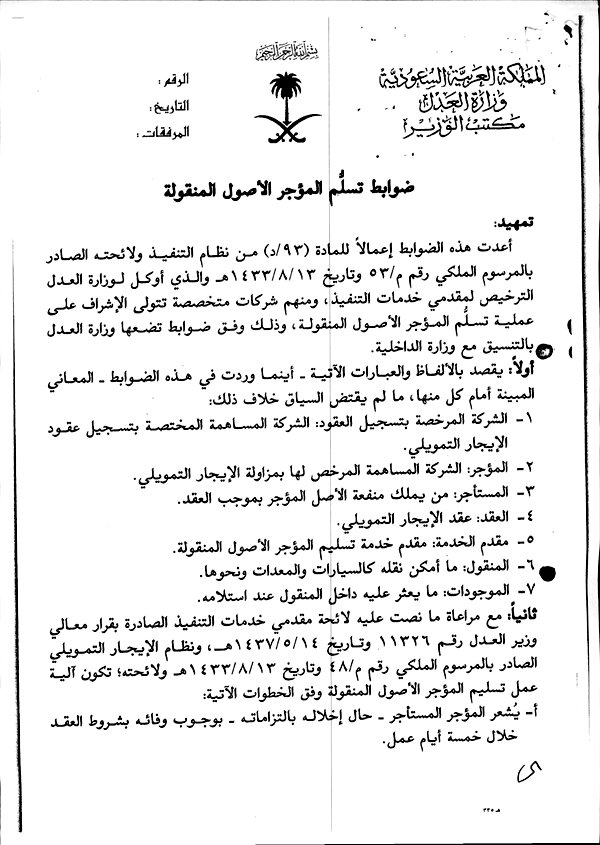

In [ ]:
sample_image_path = "/gdrive/MyDrive/Finetune_OCR_Arabic_COURSE/images/file_5/page_002.jpg"

display(IPImage(filename=sample_image_path))

________

# 2. Evaluate Base Model :

#### Hugging face login :

In [ ]:
from google.colab import userdata
hf_token = userdata.get('hugging_face')

!hf auth login --token {hf_token}

Hint: A new version of huggingface_hub (1.22.0) is available! You are using version 1.20.1.
To update, run: hf update
The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `hf`CLI if you want to set the git credential as well.
Token is valid (permission: write).
The token `ocr_arabic_test` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `ocr_arabic_test`


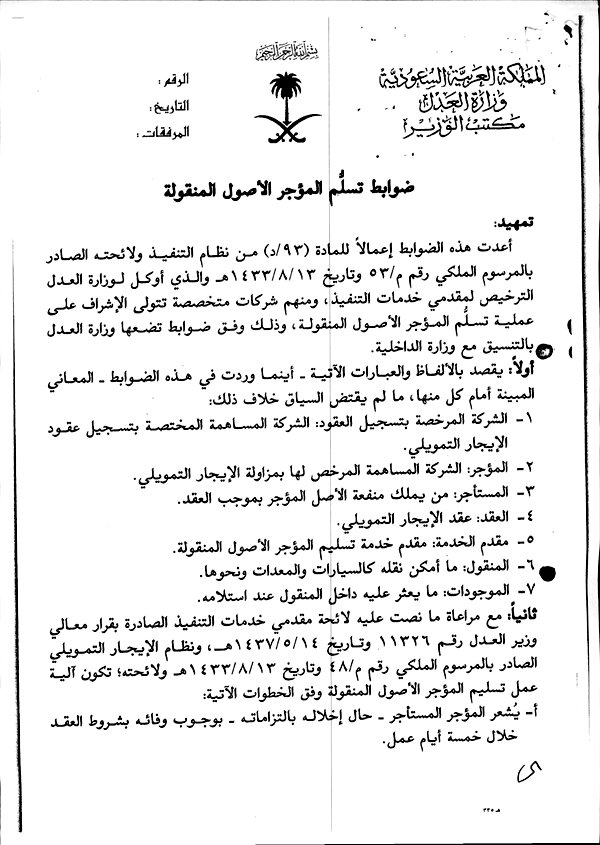

In [ ]:
model_id = "google/gemma-3-4b-it"

# Load a sample image :
sample_image_path = "/gdrive/MyDrive/Finetune_OCR_Arabic_COURSE/images/file_5/page_002.jpg"
display(IPImage(filename=sample_image_path))

### Download Base model **Gemma-3**:

In [ ]:
model = Gemma3ForConditionalGeneration.from_pretrained(
    model_id,
    dtype="auto", device_map="auto"
).eval()

processor = AutoProcessor.from_pretrained(model_id)

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/90.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

...

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

### System Prompt :

In [ ]:
prompt = """
Act as an OCR Model. Extract the exact details of the image into a markdown format.

## Outout:
```markdown
""".strip()

### Test **Gemma-3** :

In [ ]:
messages = [
    {
        "role": "system",
        "content": [{"type": "text", "text": "You are a helpful assistant."}]
    },
    {
        "role": "user",
        "content": [
            {"type": "image", "image": sample_image_path},
            {"type": "text", "text": prompt}
        ]
    }
]

inputs = processor.apply_chat_template(
    messages,

    add_generation_prompt=True, tokenize=True,
    return_dict=True, return_tensors="pt"
).to(model.device)


input_len = inputs["input_ids"].shape[-1]

with torch.inference_mode():
    generation = model.generate(**inputs, max_new_tokens=1024, do_sample=False)
    generation = generation[0][input_len:]

decoded = processor.decode(generation, skip_special_tokens=True)

[transformers] Deprecated: `processor.image_token` will switch from returning `tokenizer.image_token` to `tokenizer.boi_token` in v5.11.


In [ ]:
print(decoded)

Here's the extracted information from the image in markdown format:

```markdown
# ضوابط تسلم المؤبر الأصول المتقولة

**الرقم:**  (Not available in image)
**التاريخ:** ١٤٣٣/٠٨/١٣
**المرفقات:** (Not available in image)

**تمهيد:**
أصدرت هذه الضوابط إيعازاً للمادة (٩٢٦) من نظام التنفيذ ولائحته الصادرة بالمرسوم الملكي رقم ٥٤/٠٢ وتاريخ ١٤٣٣/٠٨/١٣، واللذي أولى لوارث العدل الترضيح لخدمىء خدمات التنفيذ، ومنهم شركات متخصصة تتولى الإشراف على عملية تسلم المؤبر الأصول المتقولة، وذلك وفق ضوابط تضعها وزارة العدل بالتنسيق مع وزارة الداخلية.

**أولاً:** يقصد بالالفاق بالأنفال والعقارات الأتية - أيبما وردت في هذه الضوابط - المعاني المبينة أمام كل منها، مما لم يقتضِ السياق خلاف ذلك:
١ - المقدم: عقد الإيجار التعويضي.
٢ - المؤبر: الشركة المساهمة المرحلة ضمن بمايزاولة الإيجار التعويضي.
٣ - المستاجر: من يملك منفعة الأصل المؤبر بموجب العقد.
٤ - العقار: عقد الإيجار التعويضي.
٥ - مقدم الخدمة: مقدم خدمة تسليم المؤبر الأصول المتقولة.
٦ - المنزل: ما أمكن نقله كالسيرات والمعدات ونحوها.
٧ - المودودات: ما يعثر عليه

## Observations on Gemma 3 OCR Performance :


### ✅ Good :

- **Good overall document understanding:** Gemma 3 correctly recognized that the document is an official Arabic government document and preserved the overall structure (title, introduction, numbered sections).

- **Accurate heading extraction:** The main title (**ضوابط تسلم المؤجر الأصول المنقولة**) and most section headers (e.g., **تمهيد**, **أولاً**, **ثانياً**) were identified correctly.

- **Strong Markdown formatting:** The model organized the output into readable Markdown with headings and numbered lists, making the extracted text easy to process.

- **Numeric recognition is partially correct:** Dates and article numbers were extracted with mixed accuracy. Some numbers were preserved correctly, while others were altered or omitted.

- **Layout understanding is better than text accuracy:** While the document hierarchy and formatting are well preserved, the transcription accuracy is insufficient for applications requiring exact text, such as legal document digitization.

### ❌ Bad :

- **Frequent OCR errors on Arabic words:** Several words were misrecognized, especially uncommon legal terminology. Examples include:
  - `المؤبر` → `المؤجر`
  - `المتقولة` → `المنقولة`
  - `الإيجار التعويضي` → `الإيجار التمويلي`
  - `المودودات` → `الموجودات`

- **Character-level mistakes:** Similar Arabic letters (e.g., ج/ب, ق/ف, ل/ك) were occasionally confused, which propagated into incorrect words.

- **Hallucinated or substituted words:** Some words that are clearly visible in the document were replaced with semantically unrelated words, suggesting the model relied on language prediction rather than visual recognition.

- **Errors in proper nouns and legal terminology:** References to ministries, regulations, and legal concepts contain multiple inaccuracies, reducing reliability for legal documents.


- **Missed metadata:** Some metadata fields (e.g., document number and attachments) were marked as unavailable despite being present in the image.

- **Incomplete extraction:** The document continues beyond the visible portion, but the extracted text ends prematurely and does not capture all visible content.

### Overall Assessment

Gemma 3 demonstrates **good document layout understanding and Markdown generation**, but its **Arabic OCR accuracy is inconsistent**, particularly on formal legal documents. The model performs reasonably well for obtaining the general content and document structure, but it introduces numerous transcription errors, word substitutions, and terminology mistakes that would require human verification before practical use.

###

__________

# 3. Synetique Data & knowledge distillation :

## Test a better cloud model (TEACHER) :

In [ ]:
from google.colab import userdata
import base64
from openai import OpenAI

openai_key = userdata.get('openai_key')

os.environ["OPENAI_API_KEY"] = openai_key

client = OpenAI()

In [ ]:
cloud_model_id = "gpt-5.5"
sample_image_path = "/gdrive/MyDrive/Finetune_OCR_Arabic_COURSE/images/file_5/page_002.jpg"

### System prompt :

In [ ]:
prompt = """
# Document Analysis & Extraction Prompt

## Task
Extract structured data from document images and return as valid JSON. Use exact enumeration values provided. Extract text in its ORIGINAL SCRIPT - never transliterate or translate names, titles, or any text unless the original is in that script.

## Output Format

```json
{
  "document_classification": {
    "type": "enum: official_letter | decree | regulation | statistical_report | table_of_contents | administrative_decision | legal_amendment | memo | certificate | form | invoice | contract | court_ruling | minutes | circular | announcement | report | other",
    "subtype": "string or null",
    "category": "enum: legal | administrative | financial | statistical | correspondence | technical | hr | other",
    "primary_language": "enum: arabic | english | french | mixed | other",
    "secondary_languages": ["array of language codes if multilingual"]
  },

  "source": {
    "issuing_authority": "string: full organization name in ORIGINAL SCRIPT",
    "department": "string or null: specific division/unit in ORIGINAL SCRIPT",
    "location": "string or null: city/region",
    "document_number": "string or null: official reference number EXACTLY as shown",
    "related_references": ["array: all other document numbers mentioned anywhere in document"],
    "dates": {
      "primary_date": {
        "date_text": "string: main document date EXACTLY as written",
        "calendar_type": "enum: hijri | gregorian | unknown",
        "date_type": "enum: issue_date | effective_date | received_date | other",
        "indicators": "string: calendar markers like 'هـ' or 'م'",
        "location_in_document": "enum: header | body | footer | stamp | other"
      },
      "additional_dates": [
        {
          "date_text": "string: EXACTLY as written",
          "calendar_type": "enum: hijri | gregorian | unknown",
          "date_type": "enum: reference_date | deadline | expiry_date | effective_date | other",
          "context": "string: brief context of where/why this date appears",
          "indicators": "string or null"
        }
      ]
    }
  },

  "physical_properties": {
    "page_number": "string: e.g., '7', '7/254', 'single', 'unknown'",
    "total_pages": "integer or null",
    "image_type": "enum: digital | scanned | photographed | mixed | unknown",
    "quality": "enum: high | medium | low | illegible",
    "color_mode": "enum: color | grayscale | black_white | mixed",
    "has_watermark": "boolean",
    "watermark_description": "string or null",
    "has_security_pattern": "boolean",
    "security_pattern_description": "string or null",
    "orientation": "enum: portrait | landscape"
  },

  "official_marks": {
    "seals": [
      {
        "organization": "string: in ORIGINAL SCRIPT",
        "position": "enum: header | footer | center | top_right | top_left | bottom_right | bottom_left | margin | overlapping_text | other",
        "description": "string: detailed visual description",
        "is_digital": "boolean",
        "shape": "enum: circular | oval | rectangular | square | irregular | other"
      }
    ],
    "stamps": [
      {
        "type": "enum: approval | received | confidential | urgent | date_stamp | routing | registry | copy | original | other",
        "text_content": "string: ALL text on stamp in ORIGINAL SCRIPT",
        "color": "enum: red | blue | black | green | purple | brown | other",
        "position": "enum: header | footer | center | top_right | top_left | bottom_right | bottom_left | margin | overlapping_text | other",
        "is_digital": "boolean",
        "shape": "enum: circular | rectangular | square | oval | irregular"
      }
    ],
    "barcodes_qr": [
      {
        "type": "enum: barcode | qr_code | data_matrix | other",
        "position": "string",
        "readable_data": "string or null"
      }
    ]
  },

  "signatures_authorization": {
    "signatories": [
      {
        "name": "string: EXACTLY as written in ORIGINAL SCRIPT (Arabic/English/etc)",
        "name_transliteration": "string or null: only if BOTH scripts appear in document",
        "title": "string: official position in ORIGINAL SCRIPT",
        "signature_type": "enum: handwritten | digital | stamp | printed_name | not_present",
        "position": "enum: bottom_left | bottom_right | bottom_center | top_right | top_left | middle_right | middle_left | end_of_document | other",
        "role": "enum: primary_signatory | co_signatory | witness | approver | preparer | reviewer | other"
      }
    ],
    "approval_chain": [
      {
        "step": "integer: order in chain (1, 2, 3...)",
        "role": "enum: prepared_by | reviewed_by | approved_by | authorized_by | noted_by | verified_by | other",
        "name": "string or null: in ORIGINAL SCRIPT",
        "title": "string or null: in ORIGINAL SCRIPT",
        "date": "string or null"
      }
    ]
  },

  "routing_distribution": {
    "addressed_to": [
      {
        "type": "enum: person | department | organization | position | general",
        "name": "string: in ORIGINAL SCRIPT",
        "honorific": "string or null: titles like 'فضيلة', 'سعادة', 'معالي'"
      }
    ],
    "carbon_copy": [
      {
        "type": "enum: person | department | organization | position",
        "name": "string: in ORIGINAL SCRIPT"
      }
    ],
    "forwarded_to": [
      {
        "type": "enum: person | department | organization | position",
        "name": "string: in ORIGINAL SCRIPT",
        "date": "string or null"
      }
    ],
    "file_reference": "string or null: internal filing/tracking code",
    "classification": "string or null: security/filing classification in ORIGINAL SCRIPT"
  },

  "content": {
    "subject": "string: document subject/title in ORIGINAL SCRIPT",
    "subject_translation": "string or null: only if explicitly needed",
    "keywords": ["array: 5-10 keywords in ORIGINAL SCRIPT"],
    "full_text": "string: complete text extraction with line breaks, in ORIGINAL SCRIPT",
    "has_tables": "boolean",
    "tables": [
      {
        "title": "string or null: in ORIGINAL SCRIPT",
        "headers": ["array: column headers in ORIGINAL SCRIPT"],
        "rows": [
          ["array of cell values per row in ORIGINAL SCRIPT"]
        ],
        "notes": "string or null"
      }
    ],
    "has_lists": "boolean",
    "lists": [
      {
        "type": "enum: numbered | bulleted | lettered | arabic_numbered | hierarchical",
        "items": ["array: items in ORIGINAL SCRIPT with hierarchy preserved"]
      }
    ],
    "has_charts": "boolean",
    "charts": [
      {
        "type": "enum: bar | line | pie | area | scatter | table | mixed | other",
        "title": "string or null: chart title in ORIGINAL SCRIPT",
        "description": "string: brief description of what chart displays",
        "data": [
          {
            "label": "string: category/bar/data point label in ORIGINAL SCRIPT",
            "value": "number or string: numerical value EXACTLY as shown",
            "position": "integer: order/sequence (1, 2, 3...)"
          }
        ],
        "axis_info": {
          "x_axis_label": "string or null: in ORIGINAL SCRIPT",
          "y_axis_label": "string or null: in ORIGINAL SCRIPT",
          "x_axis_type": "enum: categorical | numerical | date | other",
          "y_axis_type": "enum: categorical | numerical | percentage | other"
        },
        "notes": "string or null: any footnotes or additional chart info"
      }
    ],
    "legal_articles": [
      {
        "article_number": "string: in ORIGINAL SCRIPT e.g., 'المادة الأولى', 'Article 1'",
        "article_title": "string or null: in ORIGINAL SCRIPT",
        "content": "string: full article text in ORIGINAL SCRIPT"
      }
    ],
    "financial_data": [
      {
        "description": "string: in ORIGINAL SCRIPT",
        "amount": "string: numerical value EXACTLY as shown",
        "currency": "string: SAR, USD, etc. or in ORIGINAL SCRIPT"
      }
    ]
  },

  "structural_elements": {
    "header": {
      "present": "boolean",
      "content": "string or null: ALL header text in ORIGINAL SCRIPT",
      "has_logo": "boolean",
      "logo_description": "string or null",
      "reference_numbers": ["array: any reference numbers in header"]
    },
    "footer": {
      "present": "boolean",
      "content": "string or null: ALL footer text in ORIGINAL SCRIPT",
      "has_page_number": "boolean",
      "page_info": "string or null: page numbering format"
    },
    "letterhead": {
      "present": "boolean",
      "organization_name": "string or null: in ORIGINAL SCRIPT",
      "organization_name_secondary": "string or null: if in another language",
      "emblem_description": "string or null",
      "contact_info": "string or null: addresses, phones, emails, websites"
    },
    "margins_notes": {
      "has_margin_notes": "boolean",
      "margin_content": "string or null: any handwritten or printed margin notes in ORIGINAL SCRIPT"
    }
  },

  "attachments_references": {
    "attachments_mentioned": [
      {
        "description": "string: in ORIGINAL SCRIPT",
        "count": "integer or null",
        "reference_number": "string or null"
      }
    ],
    "referenced_documents": [
      {
        "type": "enum: law | regulation | decree | previous_decision | letter | circular | report | contract | minutes | other",
        "reference": "string: document identifier in ORIGINAL SCRIPT",
        "date": "string or null: if date is mentioned for this reference"
      }
    ]
  },

  "condition_notes": {
    "completeness": "enum: complete | partial | missing_pages | fragment | unknown",
    "legibility_issues": ["array: describe sections with poor legibility"],
    "physical_damage": "enum: none | minor | moderate | severe | not_applicable",
    "damage_description": "string or null",
    "handwritten_annotations": {
      "present": "boolean",
      "description": "string or null: describe notes, highlights, corrections"
    },
    "special_observations": "string or null"
  },

  "confidence_quality": {
    "overall_confidence": "enum: high | medium | low",
    "uncertain_elements": ["array: list specific elements with low confidence"],
    "requires_manual_review": "boolean",
    "review_reasons": ["array: specific areas needing verification"]
  }
}
```

## Critical Extraction Rules

### 1. ORIGINAL SCRIPT REQUIREMENT ⚠️
**MOST IMPORTANT**: Extract ALL text in its original script/language:
- Arabic names stay in Arabic: سلمان بن فوزان الفوزان (NOT "Salman bin Fawzan Al-Fawzan")
- Arabic titles stay in Arabic: القائم بعمل نائب وزير العدل (NOT translated)
- Do NOT romanize, transliterate, or translate unless the document itself shows both versions
- Preserve all diacritics and special characters exactly

### 2. Date Extraction Structure
**PRIMARY vs ADDITIONAL dates**:
- **primary_date**: The main document date (usually in header: "التاريخ")
- **additional_dates**: All other dates referenced in the body (from previous documents, deadlines, references)
- NEVER mix these - the primary date must be clearly identified
- Extract the date position: header dates are usually primary/issue dates

### 3. Name and Title Extraction
When extracting signatories or addressed persons:
```json
{
  "name": "سلمان بن فوزان الفوزان",  // ORIGINAL SCRIPT
  "title": "القائم بعمل نائب وزير العدل"  // ORIGINAL SCRIPT
}
```
NOT:
```json
{
  "name": "Salman bin Fawzan Al-Fawzan",  // WRONG - transliterated
  "title": "Acting Deputy Minister of Justice"  // WRONG - translated
}
```

### 4. Document Numbers
Extract EXACTLY as shown, preserving:
- All numbers and separators: "13/ت/8795" not "13-8795"
- Arabic and Latin characters: "م/38" not "M/38"
- Parentheses and formatting: "(م/38)" not "م/38"

### 5. Reference Numbers vs Content References
- **document_number**: The THIS document's official number (in header)
- **related_references**: OTHER document numbers mentioned in text body
- **file_reference**: Internal tracking/filing number (often in footer)

### 6. Stamps and Seals - Key Differences
**Seals** (الختم):
- Usually embossed or official emblems
- Circular/oval shapes with organization logo
- May be digital or physical
- Example: Ministry emblem at top

**Stamps** (الطابع):
- Ink impressions with text
- Rectangular/square more common
- Date stamps, approval stamps, "صورة" stamps
- Usually red, blue, or black ink

### 7. Honorifics in Routing
Capture separately:
```json
{
  "type": "position",
  "name": "نائب وزير العدل",
  "honorific": "فضيلة"
}
```
Common honorifics: فضيلة، سعادة، معالي، صاحب السمو

### 8. Header Components
Extract ALL elements from header:
- Organization name (right side usually)
- Department name
- Document number ("الرقم")
- Date ("التاريخ")
- Attachments line ("المرفقات")
- Subject line ("الموضوع")
- Reference number boxes (e.g., [277])

### 9. Chart and Graph Data Extraction
**CRITICAL**: Extract actual data values, not summaries:

For **Bar Charts**:
- Each bar = one data object with label + value
- Extract values from bars (read the number labels)
- Maintain order left-to-right or as shown
- Example for chart with 3 bars:
```json
"data": [
  {"label": "التعديلات", "value": 33, "position": 1},
  {"label": "المواد الملغية", "value": 51, "position": 2},
  {"label": "المواد والفقرات المضافة", "value": 25, "position": 3}
]
```

For **Line Charts**:
- Each point = one data object
- Extract x and y values
- Maintain sequence

For **Pie Charts**:
- Each slice = one data object with label + value/percentage

**DO NOT** create a text summary like "التعديلات: 33, المواد الملغية: 51" ❌
**DO** extract structured data array with each value as separate object ✓

Read numbers directly from:
- Value labels on/above bars
- Data point labels
- Axis tick marks
- Legend entries with values

### 10. Table Data Extraction
For tables, extract into structured format:
```json
"tables": [
  {
    "title": "عنوان الجدول",
    "headers": ["العمود الأول", "العمود الثاني", "العمود الثالث"],
    "rows": [
      ["قيمة 1-1", "قيمة 1-2", "قيمة 1-3"],
      ["قيمة 2-1", "قيمة 2-2", "قيمة 2-3"]
    ],
    "notes": "any table footnotes",
    "row_count": 2,
    "column_count": 3
  }
]
```

**Table Recognition**:
- Look for grid lines (horizontal/vertical)
- Header row usually bold or separated
- Aligned columns of data
- May have borders or just spacing

### 11. Full Text Requirements
In `full_text` field:
- Include ALL visible text
- Preserve line breaks with \n
- Keep original structure (indentation where meaningful)
- Include header, body, footer, and signatures
- Do NOT translate anything
- Include text from stamps if legible
- Include chart titles and labels (but data goes in charts section)

### 12. Referenced Documents
When document mentions other documents:
```json
{
  "type": "circular",
  "reference": "تعميم الوزارة رقم 13/ت/1839",
  "date": "12/8/1422هـ"
}
```
Extract: document type, full reference including number, and date if mentioned

## Chart and Table Extraction Examples

### Example 1: Bar Chart
For a bar chart showing three categories with values:
```json
{
  "type": "bar",
  "title": "(أ) التعديلات على النظام واللائحة",
  "description": "Bar chart showing amendments, repealed articles, and added articles",
  "data": [
    {"label": "التعديلات", "value": 33, "position": 1},
    {"label": "المواد الملغية", "value": 51, "position": 2},
    {"label": "المواد والفقرات المضافة", "value": 25, "position": 3}
  ],
  "axis_info": {
    "x_axis_label": null,
    "y_axis_label": null,
    "x_axis_type": "categorical",
    "y_axis_type": "numerical"
  },
  "notes": null
}
```

### Example 2: Multi-Category Bar Chart
For a chart with 7 different categories:
```json
{
  "type": "bar",
  "title": "(ب) المرفقات والملحقات",
  "description": "Bar chart showing counts of various legal documents and references",
  "data": [
    {"label": "لوائح متعلقة بالنظام", "value": 3, "position": 1},
    {"label": "الأحكام القضائية", "value": 98, "position": 2},
    {"label": "قرارات وتعاميم وزارة العدل", "value": 16, "position": 3},
    {"label": "تعاميم المجلس الأعلى للقضاء", "value": 32, "position": 4},
    {"label": "قرارات مجلس الوزراء ومجلس الشورى", "value": 4, "position": 5},
    {"label": "المراسيم الملكية", "value": 23, "position": 6},
    {"label": "الأوامر الملكية", "value": 4, "position": 7}
  ],
  "axis_info": {
    "x_axis_label": null,
    "y_axis_label": null,
    "x_axis_type": "categorical",
    "y_axis_type": "numerical"
  },
  "notes": null
}
```

### Example 3: Table Data
```json
{
  "title": "جدول المقارنة",
  "headers": ["البند", "العدد", "النسبة"],
  "rows": [
    ["التعديلات", "33", "30%"],
    ["المواد الملغية", "51", "46%"],
    ["المضافة", "25", "24%"]
  ],
  "notes": null,
  "row_count": 3,
  "column_count": 3
}
```

## Common Mistakes to Avoid

❌ **WRONG - Text summary instead of structured data**:
```json
"data_summary": "التعديلات: 33, المواد الملغية: 51, المواد والفقرات المضافة: 25"
```

✅ **CORRECT - Structured data array**:
```json
"data": [
  {"label": "التعديلات", "value": 33, "position": 1},
  {"label": "المواد الملغية", "value": 51, "position": 2},
  {"label": "المواد والفقرات المضافة", "value": 25, "position": 3}
]
```

❌ **WRONG - Missing values**:
```json
"axis_labels": ["التعديلات", "المواد الملغية", "المواد والفقرات المضافة"]
```

✅ **CORRECT - Labels with values**:
```json
"data": [
  {"label": "التعديلات", "value": 33, "position": 1},
  ...
]
```

❌ **WRONG - Translating labels**:
```json
{"label": "Amendments", "value": 33}
```

✅ **CORRECT - Original script**:
```json
{"label": "التعديلات", "value": 33}
```

### Saudi Official Letter/Circular Header:
```
[Logo]  المملكة العربية السعودية
        وزارة [الوزارة]
[###]   [إدارة]

الرقم: [number]         التاريخ: [date]
المرفقات: ______       الموضوع: [subject]
```

### Signature Block:
```
[Title line in Arabic]
[Handwritten signature]
[Printed name in Arabic]
```

### Footer Elements:
- Classification: "التصنيف:"
- Copy notation: "صورة لـ"
- File reference: "القيد رقم"
- Print date: "طبع في"
- Form number: "نموذج"

## Date Indicators Reference
- **هـ** or **ه** = Hijri calendar
- **م** = Gregorian (Miladi) calendar
- Format variations: ١٤٤٣/٩/١٣ or 1443/9/13 or ١٣-٩-١٤٤٣هـ
- Context: "التاريخ" means "Date", "بتاريخ" means "dated"

## Validation Checklist
Before returning JSON:
- [ ] All Arabic text kept in Arabic (not romanized)
- [ ] Primary document date separated from reference dates
- [ ] Document number vs file reference separated
- [ ] Names and titles in original script
- [ ] All enum values match specified options exactly
- [ ] No null in array fields (use empty array [])
- [ ] Valid JSON syntax (test with JSON parser)
- [ ] full_text includes all visible text
- [ ] Stamps vs seals correctly categorized

## Output Instructions
Return ONLY the JSON object. No markdown code blocks, no explanatory text. Start directly with `{` and end with `}`.
""".strip()

### Test model : **GPT-4o**

In [ ]:
# Function to encode the image
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")


# Getting the Base64 string
base64_image = encode_image(sample_image_path)


response = client.responses.create(
    model= cloud_model_id ,
    input=[
        {
            "role": "user",
            "content": [
                { "type": "input_text", "text": prompt },
                {
                    "type": "input_image",
                    "image_url": f"data:image/jpg;base64,{base64_image}",
                },
            ],
        }
    ],
)

In [ ]:
print(response.output_text)

{
  "document_classification": {
    "type": "regulation",
    "subtype": "ضوابط",
    "category": "legal",
    "primary_language": "arabic",
    "secondary_languages": []
  },
  "source": {
    "issuing_authority": "وزارة العدل",
    "department": "مكتب الوزير",
    "location": "المملكة العربية السعودية",
    "document_number": null,
    "related_references": [
      "م/٥٣",
      "١١٣٢٦",
      "م/٤٨"
    ],
    "dates": {
      "primary_date": {
        "date_text": null,
        "calendar_type": "unknown",
        "date_type": "issue_date",
        "indicators": null,
        "location_in_document": "header"
      },
      "additional_dates": [
        {
          "date_text": "١٣/٨/١٤٣٣هـ",
          "calendar_type": "hijri",
          "date_type": "reference_date",
          "context": "تاريخ المرسوم الملكي رقم م/٥٣ الصادر به نظام التنفيذ ولائحته",
          "indicators": "هـ"
        },
        {
          "date_text": "١٤/٥/١٤٣٧هـ",
          "calendar_type": "hijri",
         

## Knowledge distillation :

In [ ]:
from glob import glob
from os.path import basename, join

data_dir = data_dir = "/gdrive/MyDrive/Finetune_OCR_Arabic_COURSE/"
pdf_files = f"{data_dir}/pdfs/file_1.pdf"
output_dir = f"{data_dir}/images"
output_sft_file = join(data_dir, "ocr-image-sft.jsonl")

images_root = f"{data_dir}/images"

pdf_images_paths = {}

for folder in glob(join(images_root, "*")):
    folder_name = basename(folder)

    pdf_images_paths[folder_name] = sorted(glob(join(folder, "*.jpg")))

In [ ]:
pdf_images_paths

{'file_1': ['/gdrive/MyDrive/Finetune_OCR_Arabic_COURSE//images/file_1/page_001.jpg',
  '/gdrive/MyDrive/Finetune_OCR_Arabic_COURSE//images/file_1/page_002.jpg'],
 'file_2': ['/gdrive/MyDrive/Finetune_OCR_Arabic_COURSE//images/file_2/page_001.jpg',
  '/gdrive/MyDrive/Finetune_OCR_Arabic_COURSE//images/file_2/page_002.jpg',
  '/gdrive/MyDrive/Finetune_OCR_Arabic_COURSE//images/file_2/page_003.jpg',
  '/gdrive/MyDrive/Finetune_OCR_Arabic_COURSE//images/file_2/page_004.jpg'],
 'file_3': ['/gdrive/MyDrive/Finetune_OCR_Arabic_COURSE//images/file_3/page_001.jpg',
  '/gdrive/MyDrive/Finetune_OCR_Arabic_COURSE//images/file_3/page_002.jpg',
  '/gdrive/MyDrive/Finetune_OCR_Arabic_COURSE//images/file_3/page_003.jpg',
  '/gdrive/MyDrive/Finetune_OCR_Arabic_COURSE//images/file_3/page_004.jpg',
  '/gdrive/MyDrive/Finetune_OCR_Arabic_COURSE//images/file_3/page_005.jpg'],
 'file_4': ['/gdrive/MyDrive/Finetune_OCR_Arabic_COURSE//images/file_4/page_012.jpg',
  '/gdrive/MyDrive/Finetune_OCR_Arabic_COURSE

### Syntetique data generation :

In [ ]:
price_per_1m_input_tokens = 5.00
price_per_1m_output_tokens = 30.00
price_per_1m_cached_input_tokens = 0.50  # optional
MAX_BUDGET = 3.00  # dollars

prompt_tokens = 0
completion_tokens = 0

# ======================================================================================================================================================

def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

# ======================================================================================================================================================

ix = 0
total_cost = 0.0  # IMPORTANT: prevent undefined variable bug

for pdf_name, images in pdf_images_paths.items():

    for img in tqdm(images, desc=f"file_{pdf_name}"):

        ix += 1

        base64_image = encode_image(img)

        response = client.responses.create(
            model=cloud_model_id,
            input=[
                {
                    "role": "user",
                    "content": [
                        {"type": "input_text", "text": prompt},
                        {
                            "type": "input_image",
                            "image_url": f"data:image/jpg;base64,{base64_image}",
                        },
                    ],
                }
            ],
        )

        llm_response = response.output_text

        # Save output
        with open(output_sft_file, "a", encoding="utf8") as dest:
            dest.write(
                json.dumps(
                    {
                        "id": ix,
                        "pdf_name": pdf_name,
                        "image_path": img,
                        "model_id": cloud_model_id,
                        "output": llm_response,
                    },
                    ensure_ascii=False,
                ) + "\n"
            )

        # ✅ FIX: ResponseUsage is an object → use dot notation
        usage = response.usage
        prompt_tokens += usage.input_tokens
        completion_tokens += usage.output_tokens

        # Compute cost each iteration :
        # if ix % 1 == 0 :
        # compute cost every 3 iterations
        if ix % 3 == 0:
            cost_input = (prompt_tokens / 1_000_000) * price_per_1m_input_tokens
            cost_output = (completion_tokens / 1_000_000) * price_per_1m_output_tokens
            total_cost = cost_input + cost_output

            print(f"Iteration {ix}: Total Cost = ${total_cost:.4f}")

        # stop condition (safe now)
        if total_cost >= MAX_BUDGET:
            print(f"\nBudget of ${MAX_BUDGET:.2f} reached. Stopping.")
            break
    else:
        continue
    break

file_file_1:   0%|          | 0/2 [00:00<?, ?it/s]

file_file_2:   0%|          | 0/4 [00:00<?, ?it/s]

Iteration 3: Total Cost = $0.4827
Iteration 6: Total Cost = $1.0004


file_file_3:   0%|          | 0/5 [00:00<?, ?it/s]

Iteration 9: Total Cost = $1.4065


file_file_4:   0%|          | 0/250 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Format Dataset for Finetuning :

In [ ]:
output_dir = f"{data_dir}/images"
output_sft_file = join(data_dir, "ocr-image-sft.jsonl")

# Open the JSONL file and iterate line by line
for line in open(output_sft_file):

    rec_1 = json.loads(line.strip())

    # Stop immediately after reading the first record
    break

rec_1

{'id': 1,
 'pdf_name': 'file_1',
 'image_path': '/gdrive/MyDrive/Finetune_OCR_Arabic_COURSE//images/file_1/page_001.jpg',
 'model_id': 'gpt-5.5',
 'output': '{\n  "document_classification": {\n    "type": "circular",\n    "subtype": "منشور",\n    "category": "legal",\n    "primary_language": "arabic",\n    "secondary_languages": []\n  },\n  "source": {\n    "issuing_authority": "وزارة العدل",\n    "department": "مديرية الشؤون الجنائية والعفو",\n    "location": "الرباط",\n    "document_number": "26 - الديوان",\n    "related_references": [],\n    "dates": {\n      "primary_date": {\n        "date_text": "الرباط، في 28 يناير 1958",\n        "calendar_type": "gregorian",\n        "date_type": "issue_date",\n        "indicators": "",\n        "location_in_document": "header"\n      },\n      "additional_dates": [\n        {\n          "date_text": "15 صفر 1373",\n          "calendar_type": "hijri",\n          "date_type": "reference_date",\n          "context": "تاريخ صدور قانون المسطرة الج

#### PART 1 — Setup + configuration

In [ ]:
# Final datasets
train_ds = []
val_ds = []

# Used to avoid duplicate images
image_paths_set = set()

# Prompt used for OCR task 1 (content + structure extraction)
task_1_prompt = """
You are a professional OCR Details Extractor.
Your rule to extract: the page markdown content in addition to the structural_elements of the document.
Extract the final output into a json format.
Do not generate any introduction or conclusion.
""".strip()

# Prompt used for OCR task 2 (metadata extraction)
task_2_prompt = """
You are a professional OCR Details Extractor.
Your rule to extract the: document_classification, source, physical_properties, official_marks, signatures_authorization, routing_distribution, attachments_references, condition_notes and confidence_quality of the document.
Extract the final output into a json format.
Do not generate any introduction or conclusion.
""".strip()

# PDFs reserved for validation set :
val_pdf_files = ['file_1']



#### PART 2 — Read dataset file line by line

In [ ]:
import json_repair

def parse_json(text):
    try:
        return json_repair.loads(text)
    except:
        return None


# Open the SFT dataset file (JSONL format: one JSON per line)
for line in open(output_sft_file):

    # Skip empty lines
    if line.strip() == "":
        continue

    # Convert JSON string → Python dictionary
    rec = json.loads(line.strip())

    print("PDF NAME:", pdf_name)
    pdf_name = rec['pdf_name']

    # Try to parse LLM output into structured JSON
    llm_output = parse_json(rec['output'])

    # If parsing fails → skip this sample
    if not llm_output:
        continue

    # Skip image if already processed
    if rec['image_path'] in image_paths_set:
        continue

    # Mark image as seen
    image_paths_set.add(rec['image_path'])



    task_1_output = {
        # main OCR text content
        'content': llm_output['content'],

        # layout / structure info (optional field fallback)
        'structural_elements': llm_output.get("structural_elements", "")
    }


    # Remove fields already used in task 1
    del llm_output['content']

    if 'structural_elements' in llm_output:
        del llm_output['structural_elements']

    # Remaining fields = metadata extraction task
    task_2_output = llm_output


    task_1_sft_recored = {
        "conversations": [
            {
                "value": "<image>" + task_1_prompt,  # user input (image + instruction)
                "from": "human"
            },
            {
                # model output (structured JSON)
                "value": json.dumps(task_1_output, ensure_ascii=False, default=str),
                "from": "gpt"
            }
        ],
        "images": [
            rec['image_path']  # image input path
        ]
    }



    task_2_sft_recored = {
        "conversations": [
            {
                "value": "<image>" + task_2_prompt,
                "from": "human"
            },
            {
                "value": json.dumps(task_2_output, ensure_ascii=False, default=str),
                "from": "gpt"
            }
        ],
        "images": [
            rec['image_path']
        ]
    }


        # If PDF belongs to validation list → send to val set
    if pdf_name in val_pdf_files:
        val_ds.append(task_1_sft_recored)
        val_ds.append(task_2_sft_recored)

    # Otherwise → training set
    else:
        train_ds.append(task_1_sft_recored)
        train_ds.append(task_2_sft_recored)


    # Shuffle datasets for better training randomness
random.Random(101).shuffle(val_ds)
random.Random(101).shuffle(train_ds)


PDF NAME: file_3
PDF NAME: file_1
PDF NAME: file_1
PDF NAME: file_1
PDF NAME: file_1
PDF NAME: file_2
PDF NAME: file_2
PDF NAME: file_2
PDF NAME: file_2
PDF NAME: file_3
PDF NAME: file_3
PDF NAME: file_3
PDF NAME: file_3


In [ ]:
train_ds

[{'conversations': [{'value': '<image>You are a professional OCR Details Extractor.\nYour rule to extract: the page markdown content in addition to the structural_elements of the document.\nExtract the final output into a json format.\nDo not generate any introduction or conclusion.',
    'from': 'human'},
   {'value': '{"content": {"subject": "لائحة قسمة الأموال المشتركة", "subject_translation": null, "keywords": ["لائحة قسمة الأموال المشتركة", "المال المشترك", "دعوى القسمة", "الدائرة القضائية", "نظام المرافعات الشرعية", "منازعات القسمة", "قسمة التراضي", "قسمة الإجبار", "قائمة الجرد"], "full_text": "بسم الله الرحمن الرحيم\\n\\nالمملكة العربية السعودية\\nوزارة العدل\\nمكتب نائب الوزير\\n\\nالرقم:\\nالتاريخ:\\nالمرفقات:\\n\\nلائحة قسمة الأموال المشتركة\\n\\nالمادة الأولى:\\nيقصد بالألفاظ والعبارات الآتية أينما وردت في هذه اللائحة المعاني المبينة أمامها ما لم يقتض السياق خلاف ذلك:\\n\\n١- المال المشترك: هو المال المملوك لاثنين فأكثر على الشيوع، بموجب عقد أو إرث أو غيرهما.\\n\\n٢- دعوى ال

In [ ]:
val_ds

[{'conversations': [{'value': '<image>You are a professional OCR Details Extractor.\nYour rule to extract: the page markdown content in addition to the structural_elements of the document.\nExtract the final output into a json format.\nDo not generate any introduction or conclusion.',
    'from': 'human'},
   {'value': '{"content": {"subject": "متابعة الموظفين العموميين وصدور أحكام بحقهم – وجوب الإعلام بذلك.", "subject_translation": null, "keywords": ["الموظفين العموميين", "المتابعات الجنائية", "الاعتقال الاحتياطي", "الإدارة العامة", "الوظيفة العامة", "قانون التحقيق الجنائي", "قانون المسطرة الجنائية"], "full_text": "المملكة المغربية          وزارة العدل          مديرية التشريع والدراسات\\n\\nوزارة العدل\\nمديرية الشؤون الجنائية والعفو\\nالمنشور رقم 26 - الديوان\\n----\\n\\nالرباط، في 28 يناير 1958\\n\\nمن وزير العدل\\nإلى السيد المحامي العام لدى محكمة الاستئناف\\nبالرباط وطنجة\\n\\nالموضوع: متابعة الموظفين العموميين وصدور أحكام بحقهم – وجوب الإعلام بذلك.\\n\\nإن المتابعات الجنائية التي

In [ ]:
print("Train size:", len(train_ds))
print("Val size:", len(val_ds))

Train size: 18
Val size: 4


#### Save training/val datasets :

In [ ]:
os.makedirs(
    join(data_dir, "datasets", "llamafactory-ocr-finetune-data"), exist_ok=True
)

with open(join(data_dir, "datasets", "llamafactory-ocr-finetune-data", "train-v1.json") , "w") as dest:
    json.dump(train_ds, dest, ensure_ascii=False, default=str)

with open(join(data_dir, "datasets", "llamafactory-ocr-finetune-data", "val-v1.json") , "w") as dest:
    json.dump(val_ds, dest, ensure_ascii=False, default=str)

____

## Finetuning LLaMa factory :

#### Installations :

In [ ]:
!pip install transformers==4.57.6
!pip install optimum==1.26.0
!pip install datasets==4.4.0

!pip install torch==2.8.0
!pip install torchvision==0.23
!pip install torchaudio==2.8.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.5 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.20.1
    Uninstalling huggingface_hub-1.20.1:
      Successfully uninstalled huggingface_hub-1.20.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.12.1
    Uninstalling transformers-5.12.1:
      Successfully uninstalled transformers-5.12.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 424.5/424.5 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.5/511.5 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 16.4 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.9/887.9 MB 430.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 849.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 MB 6.2 MB/s eta 0:00:00
  Attempting uninstall: triton
    Found existing installation: triton 3.6.0
    Uninstalling triton-3.6.0:
      Successfully uninstalled triton-3.6.0
  Attempting uninstall: nvidia-nccl-cu12
    Found existing installation: nvidia-nccl-cu12 2.28.9
    Uninstalling nvidia-nccl-cu12-2.28.9:
      Successfully uninstalled nvidia-nccl-cu12-2.28.9
  Attempting uninstall: nvidia-cudnn-cu12
    Found existing installation: nvidia-cudnn-cu12 9.19.0.56
    Uninstalling nvidia-cudnn-cu12-9.19.0.56:
      Successfully uninstalled nvidia-cudnn-cu12-9.19.0.56
  Attempting uninstall: torch
    Found existing installation: torch 2.11.0+cu128
    Uninstalling torch-2.11.0+cu128:
    

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 79.4 MB/s eta 0:00:00
  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.26.0+cu128
    Uninstalling torchvision-0.26.0+cu128:
      Successfully uninstalled torchvision-0.26.0+cu128


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 62.2 MB/s eta 0:00:00
  Attempting uninstall: torchaudio
    Found existing installation: torchaudio 2.11.0+cu128
    Uninstalling torchaudio-2.11.0+cu128:
      Successfully uninstalled torchaudio-2.11.0+cu128


KeyboardInterrupt: 

In [ ]:
!git clone --depth 1 https://github.com/hiyouga/LlamaFactory.git
!cd LlamaFactory && git checkout 762b480131908d37736ad9aa3f12e87f8f7e6313

!cd LlamaFactory && pip install -e .
!cd LlamaFactory && pip install -r requirements/metrics.txt

Cloning into 'LlamaFactory'...
remote: Enumerating objects: 680, done.
remote: Counting objects: 100% (680/680), done.
remote: Compressing objects: 100% (507/507), done.
remote: Total 680 (delta 148), reused 483 (delta 108), pack-reused 0 (from 0)
Receiving objects: 100% (680/680), 5.38 MiB | 5.85 MiB/s, done.
Resolving deltas: 100% (148/148), done.
fatal: reference is not a tree: 762b480131908d37736ad9aa3f12e87f8f7e6313
Obtaining file:///content/LlamaFactory
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.8/375.8 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

#### Setup files :

in `LlamaFactory/data/dataset_info.json`

you can find it in `/content/LlamaFactory/data/dataset_info.json`

add

```json
"ocr_finetune_train": {
            "file_name": "/gdrive/MyDrive/Finetune_OCR_Arabic_COURSE/datasets/llamafactory-ocr-finetune-data/train-v1.json",
            "formatting": "sharegpt",
            "columns": {
                "messages": "conversations",
                "images": "images"
            }
    },
    "ocr_finetune_val": {
        "file_name": "/gdrive/MyDrive/Finetune_OCR_Arabic_COURSE/datasets/llamafactory-ocr-finetune-data/val-v1.json",
        "formatting": "sharegpt",
        "columns": {
            "messages": "conversations",
            "images": "images"
        }
    }
```

in `workspace/LlamaFactory/examples/train_lora/ocr_finetune.yaml`

add

```yaml
### model
model_name_or_path: google/gemma-3-4b-it
use_fast_tokenizer: false
cache_dir: /workspace/cache
trust_remote_code: true

### method
stage: sft
do_train: true
finetuning_type: lora
lora_rank: 96
lora_target: all

### dataset
dataset: ocr_finetune_train
eval_dataset: ocr_finetune_val
template: gemma3
cutoff_len: 12000
# max_samples: 50
overwrite_cache: true
preprocessing_num_workers: 16

### output
resume_from_checkpoint: /workspace/ocr-models-gemma-3-4b-it/checkpoint-100
output_dir: /workspace/ocr-models-gemma-3-4b-it/
logging_steps: 25
save_steps: 50
plot_loss: true
# overwrite_output_dir: true

### train
per_device_train_batch_size: 1
gradient_accumulation_steps: 8
learning_rate: 1.0e-4
num_train_epochs: 20.0
lr_scheduler_type: cosine
warmup_ratio: 0.1
bf16: true
ddp_timeout: 180000000

### eval
# val_size: 0.1
per_device_eval_batch_size: 1
eval_strategy: steps
eval_steps: 50

report_to: wandb
run_name: yt-ocr-finetune-llamafactory

# push_to_hub: true
# export_hub_model_id: "bakrianoo/arabic-legal-documents-ocr-parser-1.0"
# hub_private_repo: true
# hub_strategy: checkpoint

```

### Train

In [ ]:
from google.colab import userdata


!hf auth login --token {hf_token}

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `hf`CLI if you want to set the git credential as well.
Token is valid (permission: write).
The token `ocr_arabic_test` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `ocr_arabic_test`


In [ ]:
!cd LlamaFactory &&export DISABLE_VERSION_CHECK=1 && llamafactory-cli train /content/LlamaFactory/examples/train_lora/ocr_finetune.yaml

Streaming output truncated to the last 5000 lines.
	257360: AddedToken("<unused1458>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=False),
	257361: AddedToken("<unused1459>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=False),
	257362: AddedToken("<unused1460>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=False),
	257363: AddedToken("<unused1461>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=False),
	257364: AddedToken("<unused1462>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=False),
	257365: AddedToken("<unused1463>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=False),
	257366: AddedToken("<unused1464>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=False),
	257367: AddedToken("<unused1465>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=False),
	257368: Adde